In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow: 2.19.0
Num GPUs Available:  1


In [3]:
# 1. Load Data
df = pd.read_csv("dataset/train.csv")

# 2. Pivot Data to Wide Format (One row per image, 5 target columns)
# We need to pivot on 'image_path' (or sample_id) and 'target_name'
pivot_df = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()

# Ensure columns are in a consistent order
target_cols = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
pivot_df = pivot_df[['image_path'] + target_cols]

# Fill NaNs if any (though dataset seems complete, good practice)
pivot_df[target_cols] = pivot_df[target_cols].fillna(0.0)

print("Pivoted Shape:", pivot_df.shape)
display(pivot_df.head())

Pivoted Shape: (357, 6)


target_name,image_path,Dry_Green_g,Dry_Dead_g,Dry_Clover_g,GDM_g,Dry_Total_g
0,train/ID1011485656.jpg,16.2751,31.9984,0.0000,16.2750,48.2735
1,train/ID1012260530.jpg,7.6000,0.0000,0.0000,7.6000,7.6000
2,train/ID1025234388.jpg,0.0000,0.0000,6.0500,6.0500,6.0500
3,train/ID1028611175.jpg,24.2376,30.9703,0.0000,24.2376,55.2079
4,train/ID1035947949.jpg,10.5261,23.2239,0.4343,10.9605,34.1844


In [4]:
# 3. Split Data
train_df, val_df = train_test_split(pivot_df, test_size=0.2, random_state=42)

print("Train images:", len(train_df))
print("Val images:", len(val_df))

Train images: 285
Val images: 72


In [6]:
# 4. Create TensorFlow Dataset
IMG_SIZE = 512
BATCH_SIZE = 16

def load_image(path):
    # Load and preprocess image
    img = tf.io.read_file("dataset/" + path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img

def create_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    # Inputs: Image paths
    image_paths = dataframe['image_path'].values
    
    # Outputs: 5 Target values
    targets = dataframe[target_cols].values.astype(np.float32)
    
    ds = tf.data.Dataset.from_tensor_slices((image_paths, targets))
    
    def map_func(path, target):
        return load_image(path), target
    
    ds = ds.map(map_func, num_parallel_calls=tf.data.AUTOTUNE)
    
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)
        
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = create_dataset(train_df, shuffle=True)
val_ds = create_dataset(val_df, shuffle=False)

# Verify shapes
for img_batch, target_batch in train_ds.take(1):
    print("Image batch shape:", img_batch.shape)
    print("Target batch shape:", target_batch.shape)
    print("Sample targets:", target_batch[0].numpy())

Image batch shape: (16, 512, 512, 3)
Target batch shape: (16, 5)
Sample targets: [ 8.4829  8.2099  2.1841 10.667  18.877 ]


2025-11-24 01:31:04.153792: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [19]:
for image, targets in train_ds.take(1):
    print(targets)

tf.Tensor(
[[ 60.2      2.4      0.      60.2     62.6   ]
 [  0.      18.1125  43.2687  43.2687  61.3813]
 [ 21.0896  13.0842   0.      21.0896  34.1738]
 [  0.       6.8619  19.9619  19.9619  26.8238]
 [ 73.0137  33.5863   0.      73.0137 106.6   ]
 [  6.1574   5.0118   0.       6.1574  11.1692]
 [ 24.5143   4.7143   3.7714  28.2857  33.    ]
 [ 59.5557   0.3443   0.      59.5557  59.9   ]
 [  0.8      0.      40.03    40.83    40.83  ]
 [ 55.6108   8.6892   0.      55.6108  64.3   ]
 [ 17.2131  24.7869   0.      17.2131  42.    ]
 [ 31.5263  10.3894   0.      31.5264  41.9157]
 [  7.8111  23.277    2.812   10.623   33.9   ]
 [ 17.4087   4.2957  11.3043  28.713   33.0087]
 [ 37.1257  10.3826   0.      37.1257  47.5083]
 [104.1503   5.4497   0.     104.1503 109.6   ]], shape=(16, 5), dtype=float32)


2025-11-24 01:35:57.468402: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


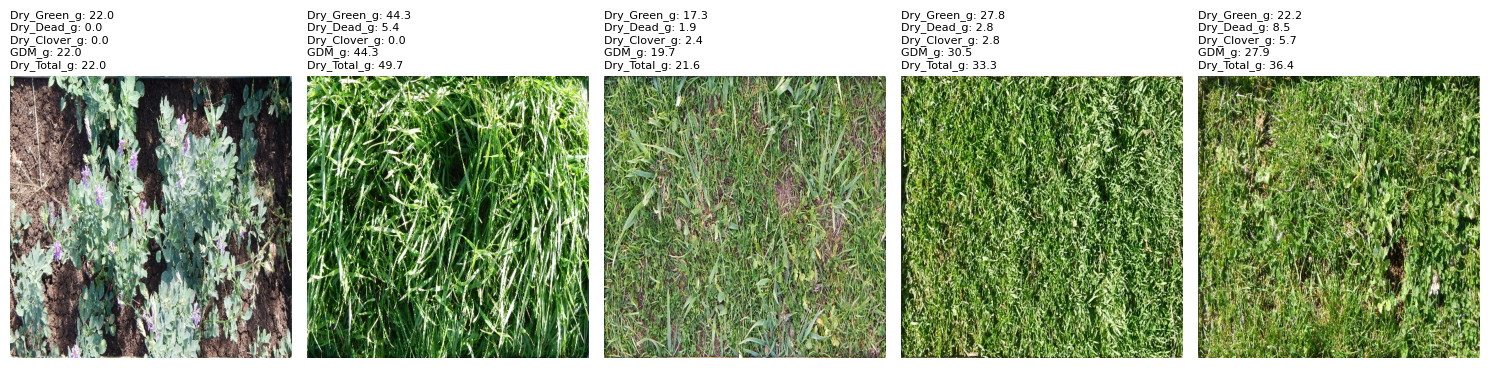

In [16]:
import matplotlib.pyplot as plt

target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']

plt.figure(figsize=(15, 5))
for images, targets in train_ds.take(1):
    for i in range(5):
        ax = plt.subplot(1, 5, i + 1)
        plt.imshow(images[i].numpy())
        
        # Create a string for the targets
        t = targets[i].numpy()
        title_str = "\n".join([f"{n}: {v:.1f}" for n, v in zip(target_names, t)])
        
        plt.title(title_str, fontsize=8, loc='left')
        plt.axis("off")
plt.tight_layout()
plt.show()

## BUILDING THE MODEL NOW

In [22]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, Activation, Add, Input

from tensorflow.keras.models import Model



inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Initial Conv Block
x = Conv2D(32, 3, strides=2, padding='same', activation='relu')(inputs)
x = Conv2D(64, 3, padding='same', activation='relu')(x)

# Residual Block 1
res = x
x = Conv2D(64, 3, padding='same', activation='relu')(x)
x = Conv2D(64, 3, padding='same')(x)
x = Add()([x, res])
x = Activation('relu')(x)
x = MaxPooling2D()(x)  # Downsample

# Residual Block 2
res = Conv2D(128, 1, strides=2, padding='same')(x)  # Match dims
x = Conv2D(128, 3, strides=2, padding='same', activation='relu')(x)
x = Conv2D(128, 3, padding='same')(x)
x = Add()([x, res])
x = Activation('relu')(x)

# Residual Block 3
res = Conv2D(256, 1, strides=2, padding='same')(x)
x = Conv2D(256, 3, strides=2, padding='same', activation='relu')(x)
x = Conv2D(256, 3, padding='same')(x)
x = Add()([x, res])
x = Activation('relu')(x)

# Global Pooling + Dense
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# Output: 5 regression values
outputs = Dense(5)(x)

model = Model(inputs, outputs)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 512, 512,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 256, 256,  │     18,496 │ conv2d_20[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 256, 256,  │     36,928 │ conv2d_22[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 256, 256,  │          0 │ conv2d_23[0][0],  │
│                     │ 64)               │            │ conv2d_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 256, 256,  │          0 │ add_6[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ activation_6[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_25[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │      8,320 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 64,    │          0 │ conv2d_26[0][0],  │
│                     │ 128)              │            │ conv2d_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 64, 64,    │          0 │ add_7[0][0]       │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 32, 32,    │    295,168 │ activation_7[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_28[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 32, 32,    │     33,024 │ activation_7[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 32, 32,    │          0 │ conv2d_29[0][0],

 Total params: 1,274,821 (4.86 MB)

 Trainable params: 1,274,821 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

# we will assign weights to the output parameters

In [23]:
import tensorflow.keras.backend as K

def weighted_r2(y_true, y_pred):
    # Weights for the 5 biomass components
    # Dry_Green_g, Dry_Dead_g, Dry_Clover_g, GDM_g, Dry_Total_g
    weights = tf.constant([0.1, 0.1, 0.1, 0.2, 0.5], dtype=tf.float32)
    
    # Total Sum of Squares (TSS)
    mean_y_true = K.mean(y_true, axis=0)
    tss = K.sum(K.square(y_true - mean_y_true), axis=0)
    
    # Residual Sum of Squares (RSS)
    rss = K.sum(K.square(y_true - y_pred), axis=0)
    
    # R2 for each component: 1 - (RSS / (TSS + epsilon))
    # Adding epsilon to avoid division by zero
    r2_scores = 1 - (rss / (tss + K.epsilon()))
    
    # Weighted Average R2
    weighted_r2_score = K.sum(r2_scores * weights)
    
    return weighted_r2_score

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae', weighted_r2]
)


In [ ]:
# Callbacks
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras', 
    monitor='val_weighted_r2', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_weighted_r2', 
    mode='max', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_weighted_r2', 
    mode='max', 
    factor=0.5, 
    patience=5, 
    min_lr=1e-6,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stopping, reduce_lr]
)


Epoch 1/50


I0000 00:00:1763928951.769640   23018 service.cc:152] XLA service 0x7b07d8016d10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763928951.769667   23018 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-11-24 01:45:51.829525: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763928952.195588   23018 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/18 ━━━━━━━━━━━━━━━━━━━━ 6:27 23s/step - loss: 947.5345 - mae: 23.4983 - weighted_r2: -4.6612

I0000 00:00:1763928972.020402   23018 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - loss: 1317.5316 - mae: 25.2131 - weighted_r2: -2.7921

2025-11-24 01:46:15.483182: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_814', 8 bytes spill stores, 8 bytes spill loads



18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 1315.9832 - mae: 25.1737 - weighted_r2: -2.7717   

2025-11-24 01:46:39.427784: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_165', 8 bytes spill stores, 8 bytes spill loads




Epoch 1: val_weighted_r2 improved from None to -2.57596, saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - loss: 1289.6578 - mae: 24.5045 - weighted_r2: -2.4257 - val_loss: 950.9462 - val_mae: 21.2568 - val_weighted_r2: -2.5760 - learning_rate: 1.0000e-04
Epoch 2/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - loss: 1021.1950 - mae: 20.7666 - weighted_r2: -1.1964
Epoch 2: val_weighted_r2 improved from -2.57596 to -0.25065, saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 196ms/step - loss: 797.8892 - mae: 19.0613 - weighted_r2: -0.9136 - val_loss: 405.2121 - val_mae: 14.4806 - val_weighted_r2: -0.2507 - learning_rate: 1.0000e-04
Epoch 3/50
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - loss: 568.6069 - mae: 16.5248 - weighted_r2: -0.3537
Epoch 3: val_weighted_r2 improved from -0.25065 to -0.21259, saving model to best_model.keras
18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 192ms/step - loss: 574.7203 - mae: 16.6012 - weighted_r2: -0.4131 - val_loss: 395.4940 - val_ma

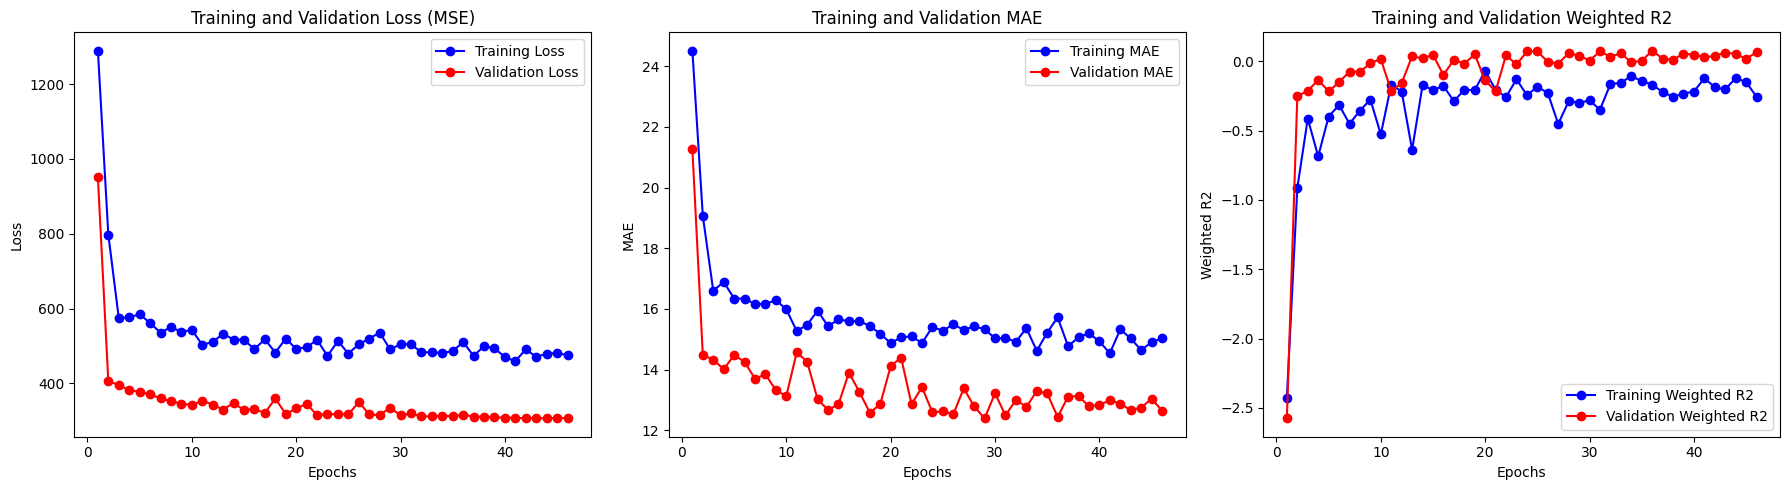

In [25]:
import matplotlib.pyplot as plt

def plot_history(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    mae = history.history['mae']
    val_mae = history.history['val_mae']
    r2 = history.history['weighted_r2']
    val_r2 = history.history['val_weighted_r2']
    
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(18, 5))
    
    # Plot Loss
    plt.subplot(1, 3, 1)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss (MSE)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    # Plot MAE
    plt.subplot(1, 3, 2)
    plt.plot(epochs, mae, 'bo-', label='Training MAE')
    plt.plot(epochs, val_mae, 'ro-', label='Validation MAE')
    plt.title('Training and Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    
    # Plot Weighted R2
    plt.subplot(1, 3, 3)
    plt.plot(epochs, r2, 'bo-', label='Training Weighted R2')
    plt.plot(epochs, val_r2, 'ro-', label='Validation Weighted R2')
    plt.title('Training and Validation Weighted R2')
    plt.xlabel('Epochs')
    plt.ylabel('Weighted R2')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)


In [26]:
model.save("model5.h5")

Generating predictions for validation set...

Overall Weighted R2 Score: 0.1349
Component R2 Scores:
  Dry_Green_g    : 0.1879
  Dry_Dead_g     : -0.0971
  Dry_Clover_g   : -0.0290
  GDM_g          : 0.2292
  Dry_Total_g    : 0.1657

Visualizing 5 random samples...


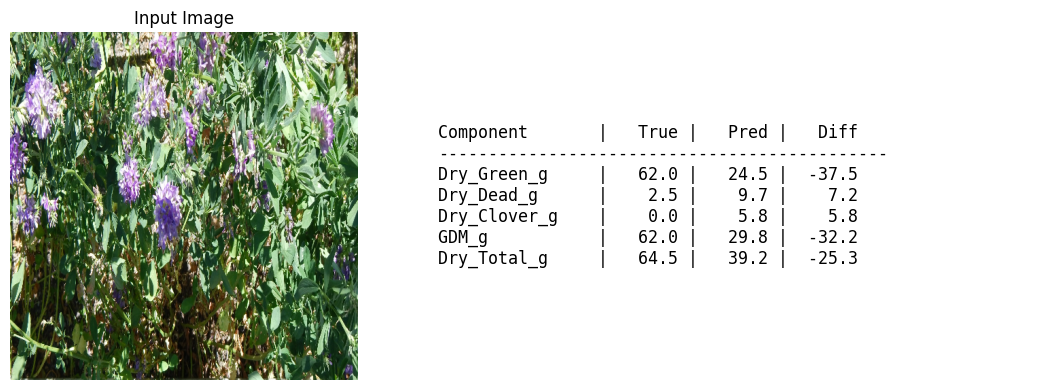

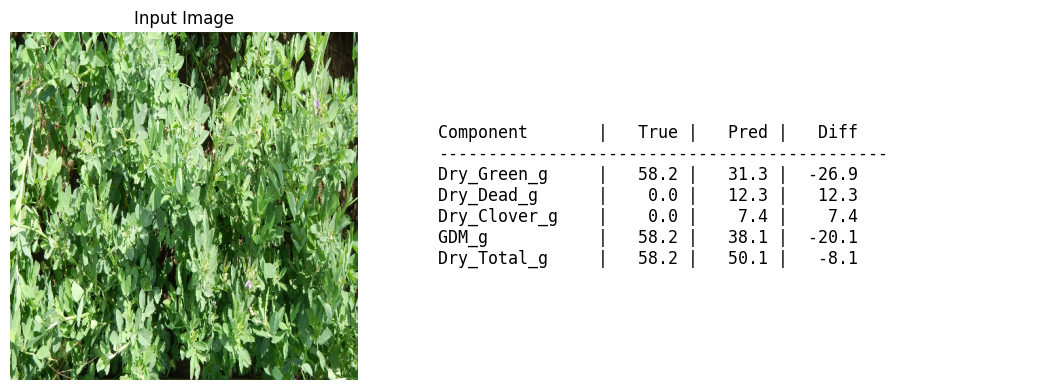

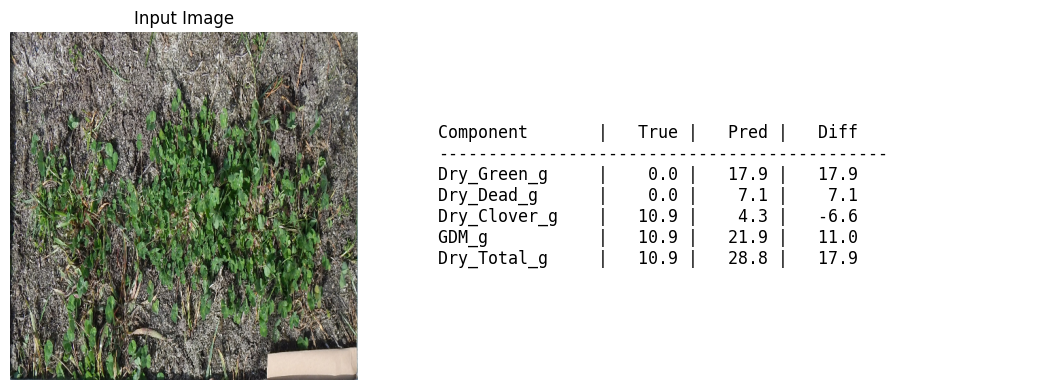

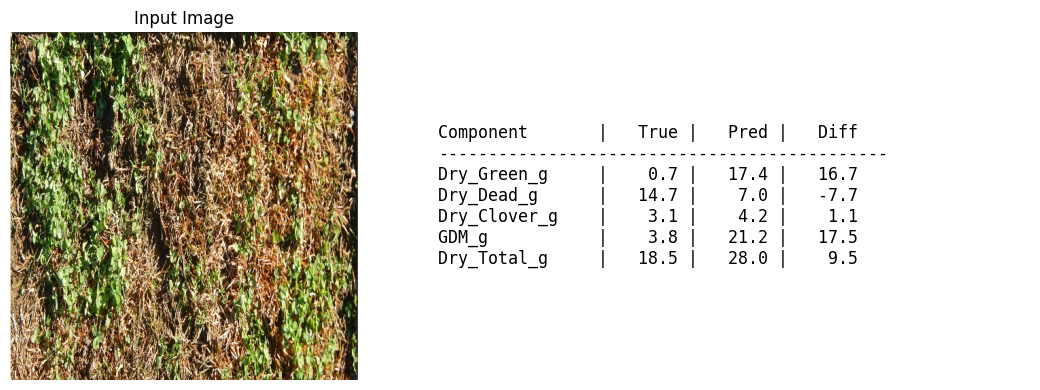

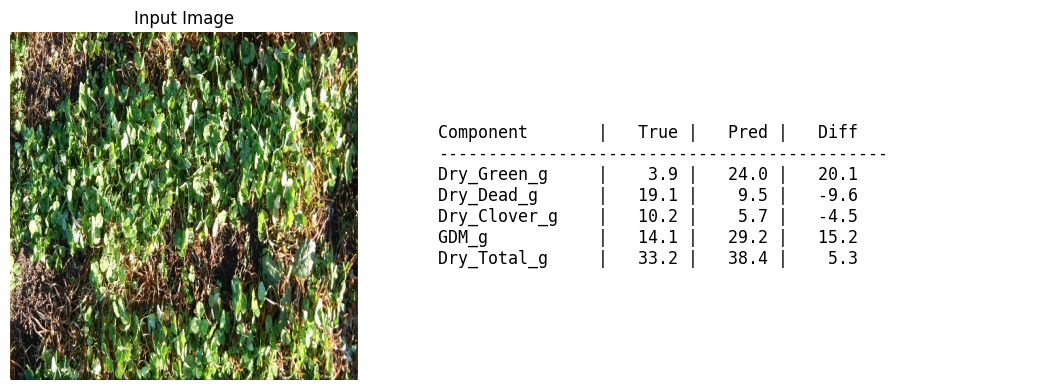

In [27]:
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(model, val_ds, num_samples=5):
    # 1. Get all predictions and true values
    all_images = []
    all_targets = []
    all_preds = []
    
    print("Generating predictions for validation set...")
    # Unbatch the dataset to process all samples
    for images, targets in val_ds:
        preds = model.predict(images, verbose=0)
        all_images.append(images.numpy())
        all_targets.append(targets.numpy())
        all_preds.append(preds)
        
    # Concatenate batches
    all_images = np.concatenate(all_images, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    all_preds = np.concatenate(all_preds, axis=0)
    
    # 2. Calculate Overall Weighted R2
    weights = np.array([0.1, 0.1, 0.1, 0.2, 0.5])
    
    mean_true = np.mean(all_targets, axis=0)
    tss = np.sum((all_targets - mean_true)**2, axis=0)
    rss = np.sum((all_targets - all_preds)**2, axis=0)
    
    # Avoid division by zero
    r2_scores = 1 - (rss / (tss + 1e-7))
    weighted_r2 = np.sum(r2_scores * weights)
    
    print(f"\nOverall Weighted R2 Score: {weighted_r2:.4f}")
    print(f"Component R2 Scores:")
    target_names = ['Dry_Green_g', 'Dry_Dead_g', 'Dry_Clover_g', 'GDM_g', 'Dry_Total_g']
    for name, score in zip(target_names, r2_scores):
        print(f"  {name:<15}: {score:.4f}")
        
    # 3. Visualize Samples
    print(f"\nVisualizing {num_samples} random samples...")
    indices = np.random.choice(len(all_images), num_samples, replace=False)
    
    for idx in indices:
        img = all_images[idx]
        true = all_targets[idx]
        pred = all_preds[idx]
        
        plt.figure(figsize=(12, 4))
        
        # Image
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title("Input Image")
        
        # Table of values
        plt.subplot(1, 2, 2)
        plt.axis('off')
        
        # Header
        text_str = f"{'Component':<15} | {'True':>6} | {'Pred':>6} | {'Diff':>6}\n"
        text_str += "-"*45 + "\n"
        
        # Rows
        for i, name in enumerate(target_names):
            diff = pred[i] - true[i]
            text_str += f"{name:<15} | {true[i]:6.1f} | {pred[i]:6.1f} | {diff:6.1f}\n"
            
        plt.text(0, 0.5, text_str, fontsize=12, family='monospace', va='center')
        plt.tight_layout()
        plt.show()

# Run evaluation
evaluate_and_visualize(model, val_ds)
